In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [12]:
# Generate mock sensor data
def generate_mock_sensor_data(num_rows=100, start_time=None):
    if start_time is None:
        start_time = datetime.utcnow()
    
    data = []

    for i in range(num_rows):
        timestamp = start_time + timedelta(seconds=i)

        # Simulated sensor values
        accel_x = round(np.random.normal(0, 0.05), 6)
        accel_y = round(np.random.normal(0, 0.05), 6)
        accel_z = round(np.random.normal(-1.0, 0.1), 6)

        gyro_x = round(np.random.normal(0, 0.02), 6)
        gyro_y = round(np.random.normal(0, 0.02), 6)
        gyro_z = round(np.random.normal(0, 0.02), 6)

        latitude = round(43.7369 + np.random.normal(0, 0.0001), 6)
        longitude = round(-79.26308 + np.random.normal(0, 0.0001), 6)
        altitude = round(170 + np.random.normal(0, 1), 6)
        speed = round(abs(np.random.normal(0.5, 0.2)), 4)

        data.append([
            timestamp.isoformat() + "Z",
            accel_x, accel_y, accel_z,
            gyro_x, gyro_y, gyro_z,
            latitude, longitude, altitude, speed
        ])
    
    columns = [
        'timestamp', 'accel_x', 'accel_y', 'accel_z',
        'gyro_x', 'gyro_y', 'gyro_z',
        'latitude', 'longitude', 'altitude', 'speed'
    ]

    df = pd.DataFrame(data, columns=columns)
    return df


In [13]:
# Generate mock data
mock_df = generate_mock_sensor_data(num_rows=100)


In [14]:
# Clean and process the mock data
mock_df['timestamp'] = pd.to_datetime(mock_df['timestamp'])
mock_df = mock_df.sort_values('timestamp').reset_index(drop=True)

# Apply smoothing filter
sensor_cols = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
for col in sensor_cols:
    mock_df[col] = mock_df[col].rolling(window=3, center=True, min_periods=1).mean()



In [24]:
# Smooth GPS/speed/altitude
mock_df['altitude'] = mock_df['altitude'].rolling(window=3, center=True, min_periods=1).mean()
mock_df['speed'] = mock_df['speed'].rolling(window=3, center=True, min_periods=1).mean()
mock_df['latitude'] = mock_df['latitude'].rolling(window=3, center=True, min_periods=1).mean()
mock_df['longitude'] = mock_df['longitude'].rolling(window=3, center=True, min_periods=1).mean()


In [25]:
# features calcuate 
mock_df['accel_total'] = np.sqrt(mock_df['accel_x']**2 + mock_df['accel_y']**2 + mock_df['accel_z']**2)
mock_df['gyro_total'] = np.sqrt(mock_df['gyro_x']**2 + mock_df['gyro_y']**2 + mock_df['gyro_z']**2)

In [26]:
mock_df.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,latitude,longitude,altitude,speed,accel_total,gyro_total
0,2025-06-07 14:23:33.127111+00:00,0.007532,0.049952,-0.907626,0.010415,0.017208,0.025901,43.736777,-79.262996,170.210222,0.610650,0.909031,0.032794
1,2025-06-07 14:23:34.127111+00:00,0.035644,0.012547,-0.961745,0.005718,0.021093,0.026486,43.736825,-79.262981,169.834997,0.639500,0.962487,0.034338
2,2025-06-07 14:23:35.127111+00:00,0.046768,0.003914,-0.980163,-0.002151,0.024168,0.012590,43.736842,-79.263057,170.014190,0.556367,0.981286,0.027336
3,2025-06-07 14:23:36.127111+00:00,0.039710,-0.024786,-1.046976,0.005651,0.018763,-0.011665,43.736868,-79.263008,170.298804,0.442433,1.048022,0.022804
4,2025-06-07 14:23:37.127111+00:00,-0.004598,-0.013457,-0.987513,0.006923,0.011568,-0.014531,43.736803,-79.263027,171.237305,0.397500,0.987616,0.019822


In [27]:
# Save to CSV
mock_df.to_csv("mock_features_sensor_data.csv", index=False)

print(" Mock sensor data generated and saved as 'mock_features_sensor_data.csv'")


 Mock sensor data generated and saved as 'mock_features_sensor_data.csv'


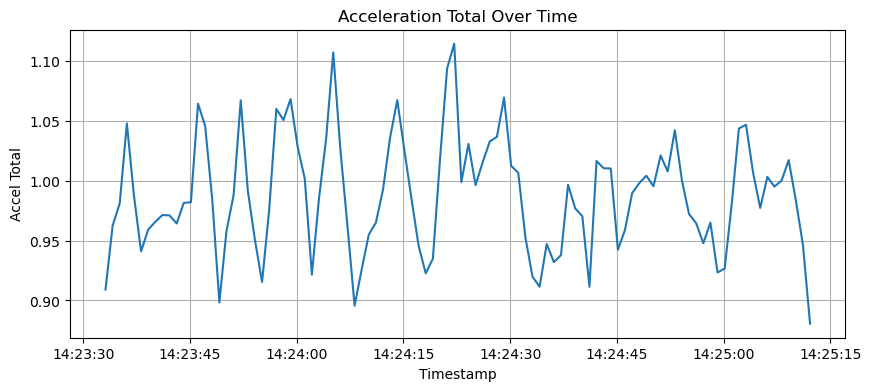

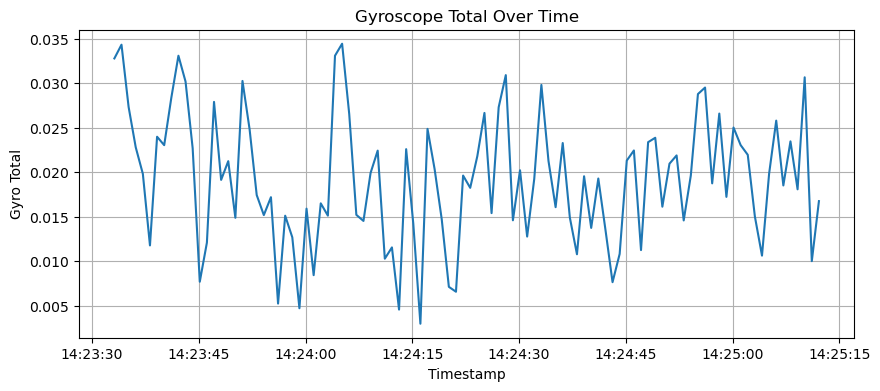

In [28]:
import matplotlib.pyplot as plt

# Plot accel_total
plt.figure(figsize=(10, 4))
plt.plot(mock_df['timestamp'], mock_df['accel_total'])
plt.title("Acceleration Total Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Accel Total")
plt.grid(True)
plt.show()

# Plot gyro_total
plt.figure(figsize=(10, 4))
plt.plot(mock_df['timestamp'], mock_df['gyro_total'])
plt.title("Gyroscope Total Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Gyro Total")
plt.grid(True)
plt.show()


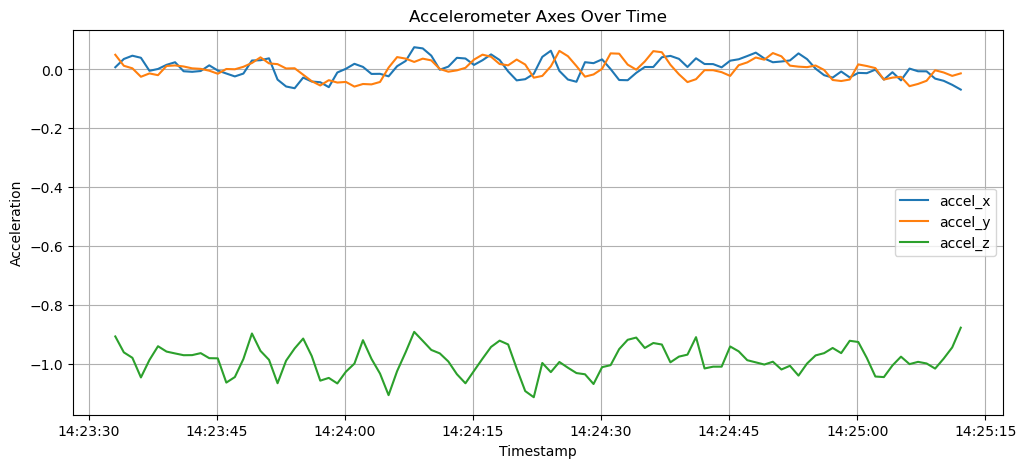

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mock_df['timestamp'], mock_df['accel_x'], label='accel_x')
plt.plot(mock_df['timestamp'], mock_df['accel_y'], label='accel_y')
plt.plot(mock_df['timestamp'], mock_df['accel_z'], label='accel_z')
plt.legend()
plt.title("Accelerometer Axes Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Acceleration")
plt.grid(True)
plt.show()


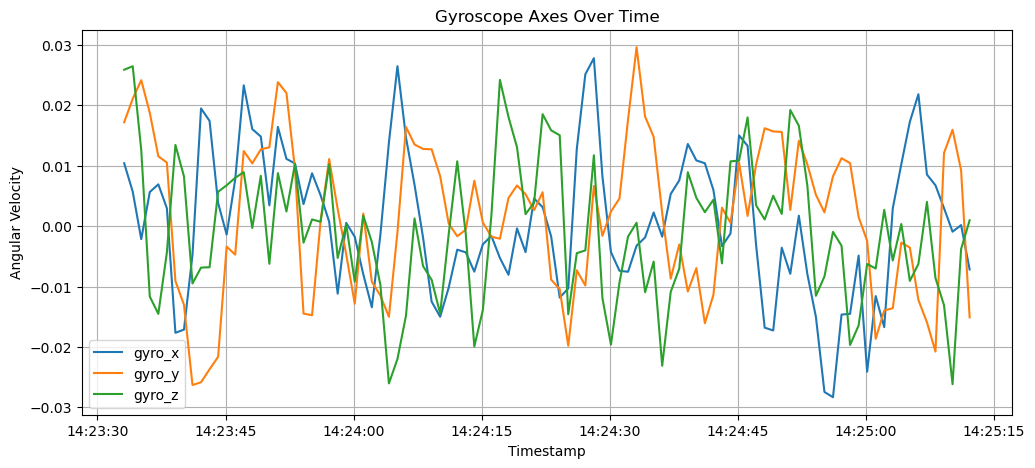

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(mock_df['timestamp'], mock_df['gyro_x'], label='gyro_x')
plt.plot(mock_df['timestamp'], mock_df['gyro_y'], label='gyro_y')
plt.plot(mock_df['timestamp'], mock_df['gyro_z'], label='gyro_z')
plt.legend()
plt.title("Gyroscope Axes Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Angular Velocity")
plt.grid(True)
plt.show()


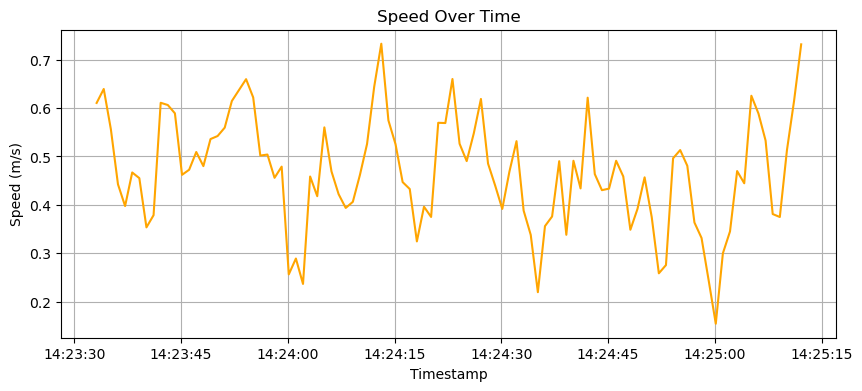

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(mock_df['timestamp'], mock_df['speed'], color='orange')
plt.title("Speed Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Speed (m/s)")
plt.grid(True)
plt.show()


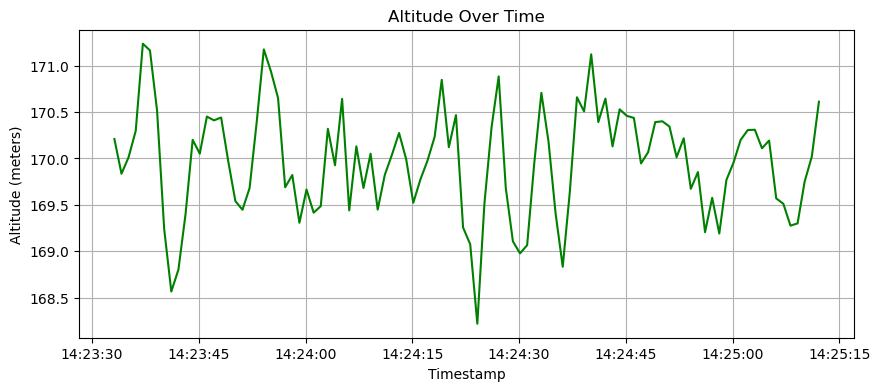

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(mock_df['timestamp'], mock_df['altitude'], color='green')
plt.title("Altitude Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Altitude (meters)")
plt.grid(True)
plt.show()


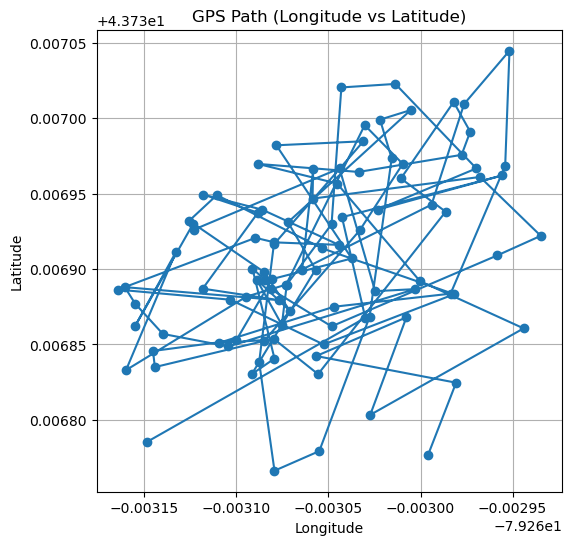

In [33]:
plt.figure(figsize=(6, 6))
plt.plot(mock_df['longitude'], mock_df['latitude'], marker='o')
plt.title("GPS Path (Longitude vs Latitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


In [35]:
import time

def simulate_logging(df, filename="logged_mock_sensor_data.csv", delay=0.2, rows=20):
    with open(filename, 'w') as f:
        f.write(','.join(df.columns) + '\n')
        for i in range(min(rows, len(df))):
            f.write(','.join(map(str, df.iloc[i].values)) + '\n')
            f.flush()
            time.sleep(delay)

simulate_logging(mock_df, rows=20)
print("Simulated streaming saved as 'logged_mock_sensor_data.csv'")


Simulated streaming saved as 'logged_mock_sensor_data.csv'


In [36]:
mock_df.to_csv("mock_features_sensor_data.csv", index=False)
print("Final cleaned data saved.")


Final cleaned data saved.


In [1]:
import pandas as pd
import numpy as np
import time


In [2]:
# Load
df = pd.read_csv("sensor_data_export_20250606_154020.csv")

# Show
df.head()


,timestamp,device_id,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,latitude,longitude,altitude,speed,activity
0,2025-06-06T15:10:32.953033Z,Apple_iPhone_7eek1jwwt,0.108719,0.028427,-0.965546,-0.012207,-0.433315,0.432334,43.7369,-79.26308,170.372546,NaN,freefall
1,2025-06-06T15:10:34.449833Z,Apple_iPhone_7eek1jwwt,0.017075,-0.049118,-0.988541,-0.002144,-0.003404,-0.003714,43.7369,-79.26308,170.372546,NaN,freefall
2,2025-06-06T15:10:35.961958Z,Apple_iPhone_7eek1jwwt,0.020584,-0.047485,-0.989822,-0.004580,-0.006383,0.001438,43.7369,-79.26308,170.372546,NaN,freefall
3,2025-06-06T15:10:37.471519Z,Apple_iPhone_7eek1jwwt,0.017715,-0.049225,-0.988556,-0.001585,-0.005021,-0.001845,43.7369,-79.26308,170.372546,NaN,freefall
4,2025-06-06T15:10:38.973162Z,Apple_iPhone_7eek1jwwt,0.016800,-0.049194,-0.988892,-0.002249,-0.004347,-0.003212,43.7369,-79.26308,170.372546,NaN,freefall


In [3]:
df = df.drop(columns=['device_id', 'activity'])  # Only if present


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)


In [5]:
sensor_cols = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
for col in sensor_cols:
    df[col] = df[col].rolling(window=3, center=True, min_periods=1).mean()


In [6]:
import numpy as np

df['accel_total'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
df['gyro_total'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)


In [7]:
df.to_csv("features_sensor_data.csv", index=False)

In [8]:
import time

def simulate_logging(df, filename, delay=1.0, rows=10):
    with open(filename, 'w') as f:
        f.write(','.join(df.columns) + '\n')
        for i in range(min(rows, len(df))):
            f.write(','.join(map(str, df.iloc[i].values)) + '\n')
            time.sleep(delay)

simulate_logging(df, "logged_sensor_data.csv", delay=0.5, rows=10)


In [37]:
def validate_sensor_row(row):
    accel_ok = -10 <= row['accel_x'] <= 10 and -10 <= row['accel_y'] <= 10 and -10 <= row['accel_z'] <= 10
    gyro_ok = -500 <= row['gyro_x'] <= 500 and -500 <= row['gyro_y'] <= 500 and -500 <= row['gyro_z'] <= 500
    gps_ok = -90 <= row['latitude'] <= 90 and -180 <= row['longitude'] <= 180
    speed_ok = 0 <= row['speed'] <= 300
    
    return accel_ok and gyro_ok and gps_ok and speed_ok


In [43]:
# Converting existing list to DataFrame
columns = ['timestamp', 'accel_x', 'accel_y', 'accel_z',
           'gyro_x', 'gyro_y', 'gyro_z',
           'latitude', 'longitude', 'altitude', 'speed']
df = mock_df.copy()


In [45]:
def simulate_connection_issues(df):
    filtered = []
    for i, row in df.iterrows():
        if i % 5 == 0:
            continue
        if random.random() < 0.1:
            continue
        filtered.append(row)
    return pd.DataFrame(filtered)

final_df = simulate_connection_issues(mock_df)

In [46]:
# Save final output
final_df.to_csv("final_sensor_data_simulated.csv", index=False)
print("Final simulated file saved.")

Final simulated file saved.
